# Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import f_oneway
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
import joblib
from sklearn.pipeline import Pipeline

# Load Data

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Machine Learning Datasets/Proyek Smart Study Predictor/student-por.csv')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


# EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [ ]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


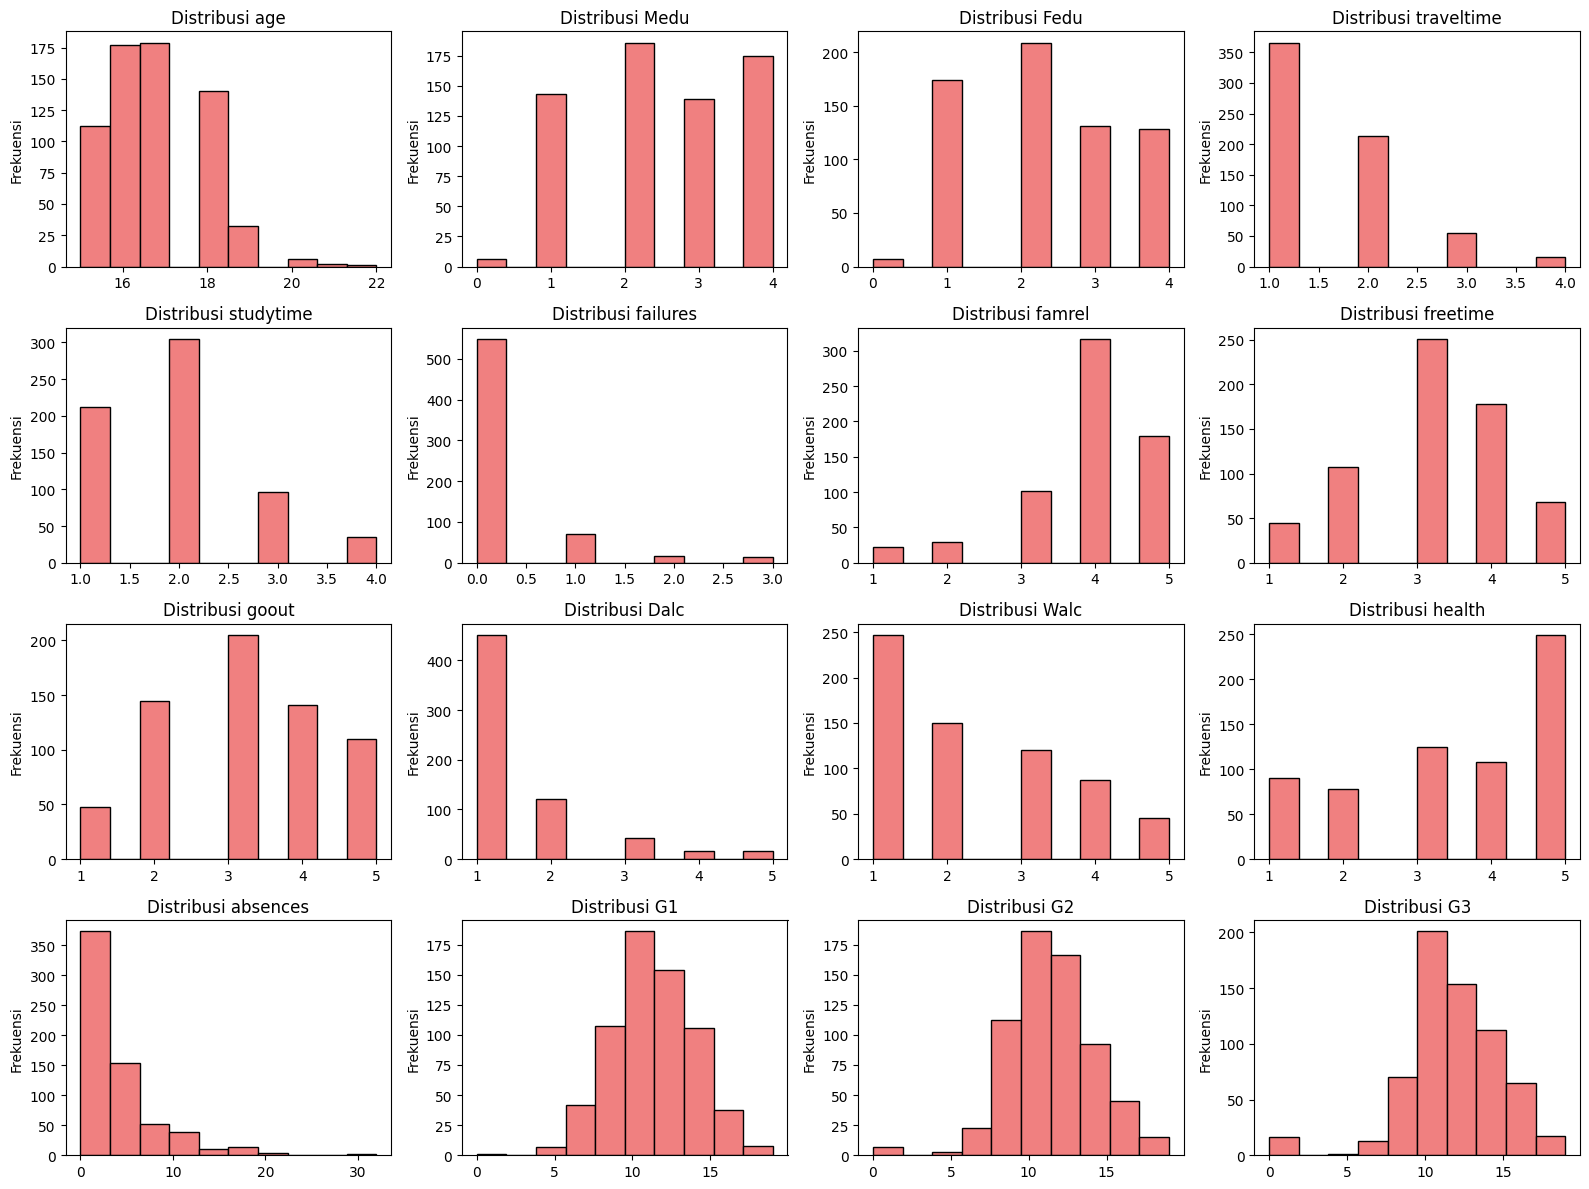

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

n_cols = 4  # Anda bisa menyesuaikan jumlah kolom di sini
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten() # Meratakan array axes agar mudah diiterasi

for i, col in enumerate(numerical_cols):
    if i < len(axes):
        axes[i].hist(df[col], bins=10, edgecolor='black', color='lightcoral')
        axes[i].set_title(f'Distribusi {col}')
        axes[i].set_xlabel('') # Menghilangkan label x agar tidak tumpang tindih
        axes[i].set_ylabel('Frekuensi')

# Menghilangkan subplot yang kosong jika ada
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

/tmp/ipykernel_1102/2177487122.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis')
/tmp/ipykernel_1102/2177487122.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis')
/tmp/ipykernel_1102/2177487122.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis')
/tmp/ipykernel_1102/2177487122.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assig

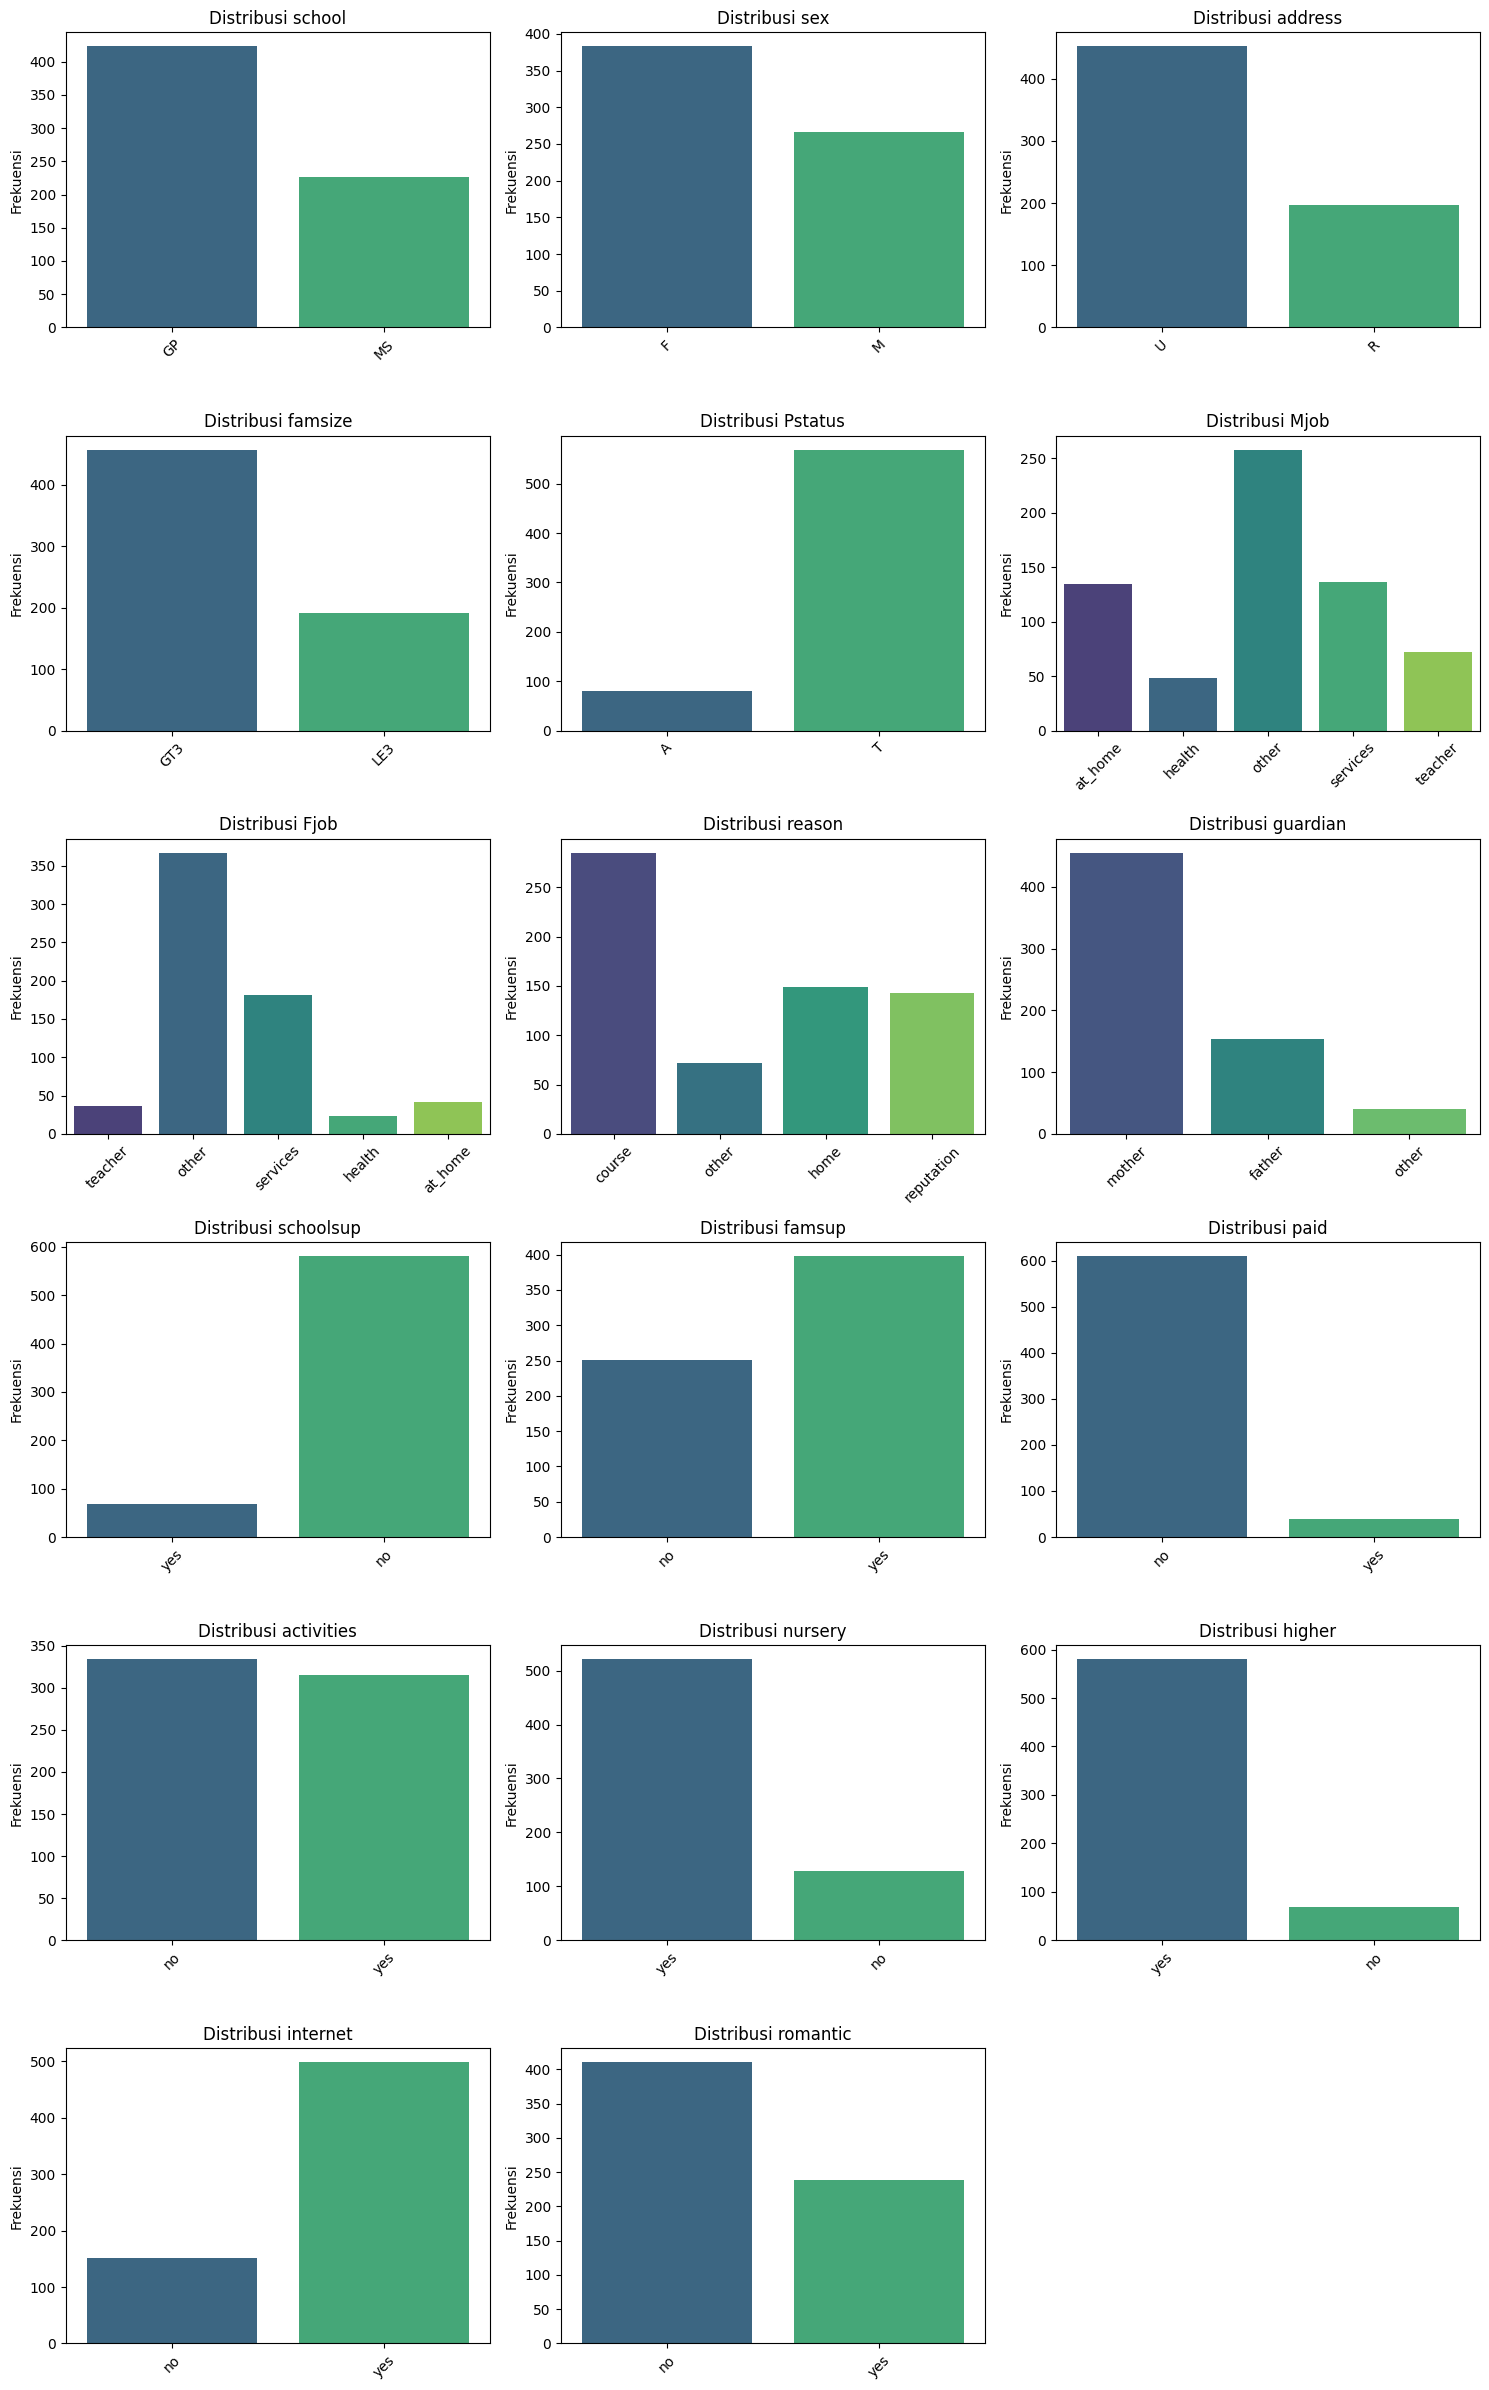

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

n_cols = 3 # Customize the number of columns in the grid
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten() # Flatten the axes array for easy iteration

for i, col in enumerate(categorical_cols):
    if i < len(axes):
        sns.countplot(data=df, x=col, ax=axes[i], palette='viridis')
        axes[i].set_title(f'Distribusi {col}')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_xlabel('') # Remove x-label to prevent overlap
        axes[i].set_ylabel('Frekuensi')

# Remove empty subplots if any
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


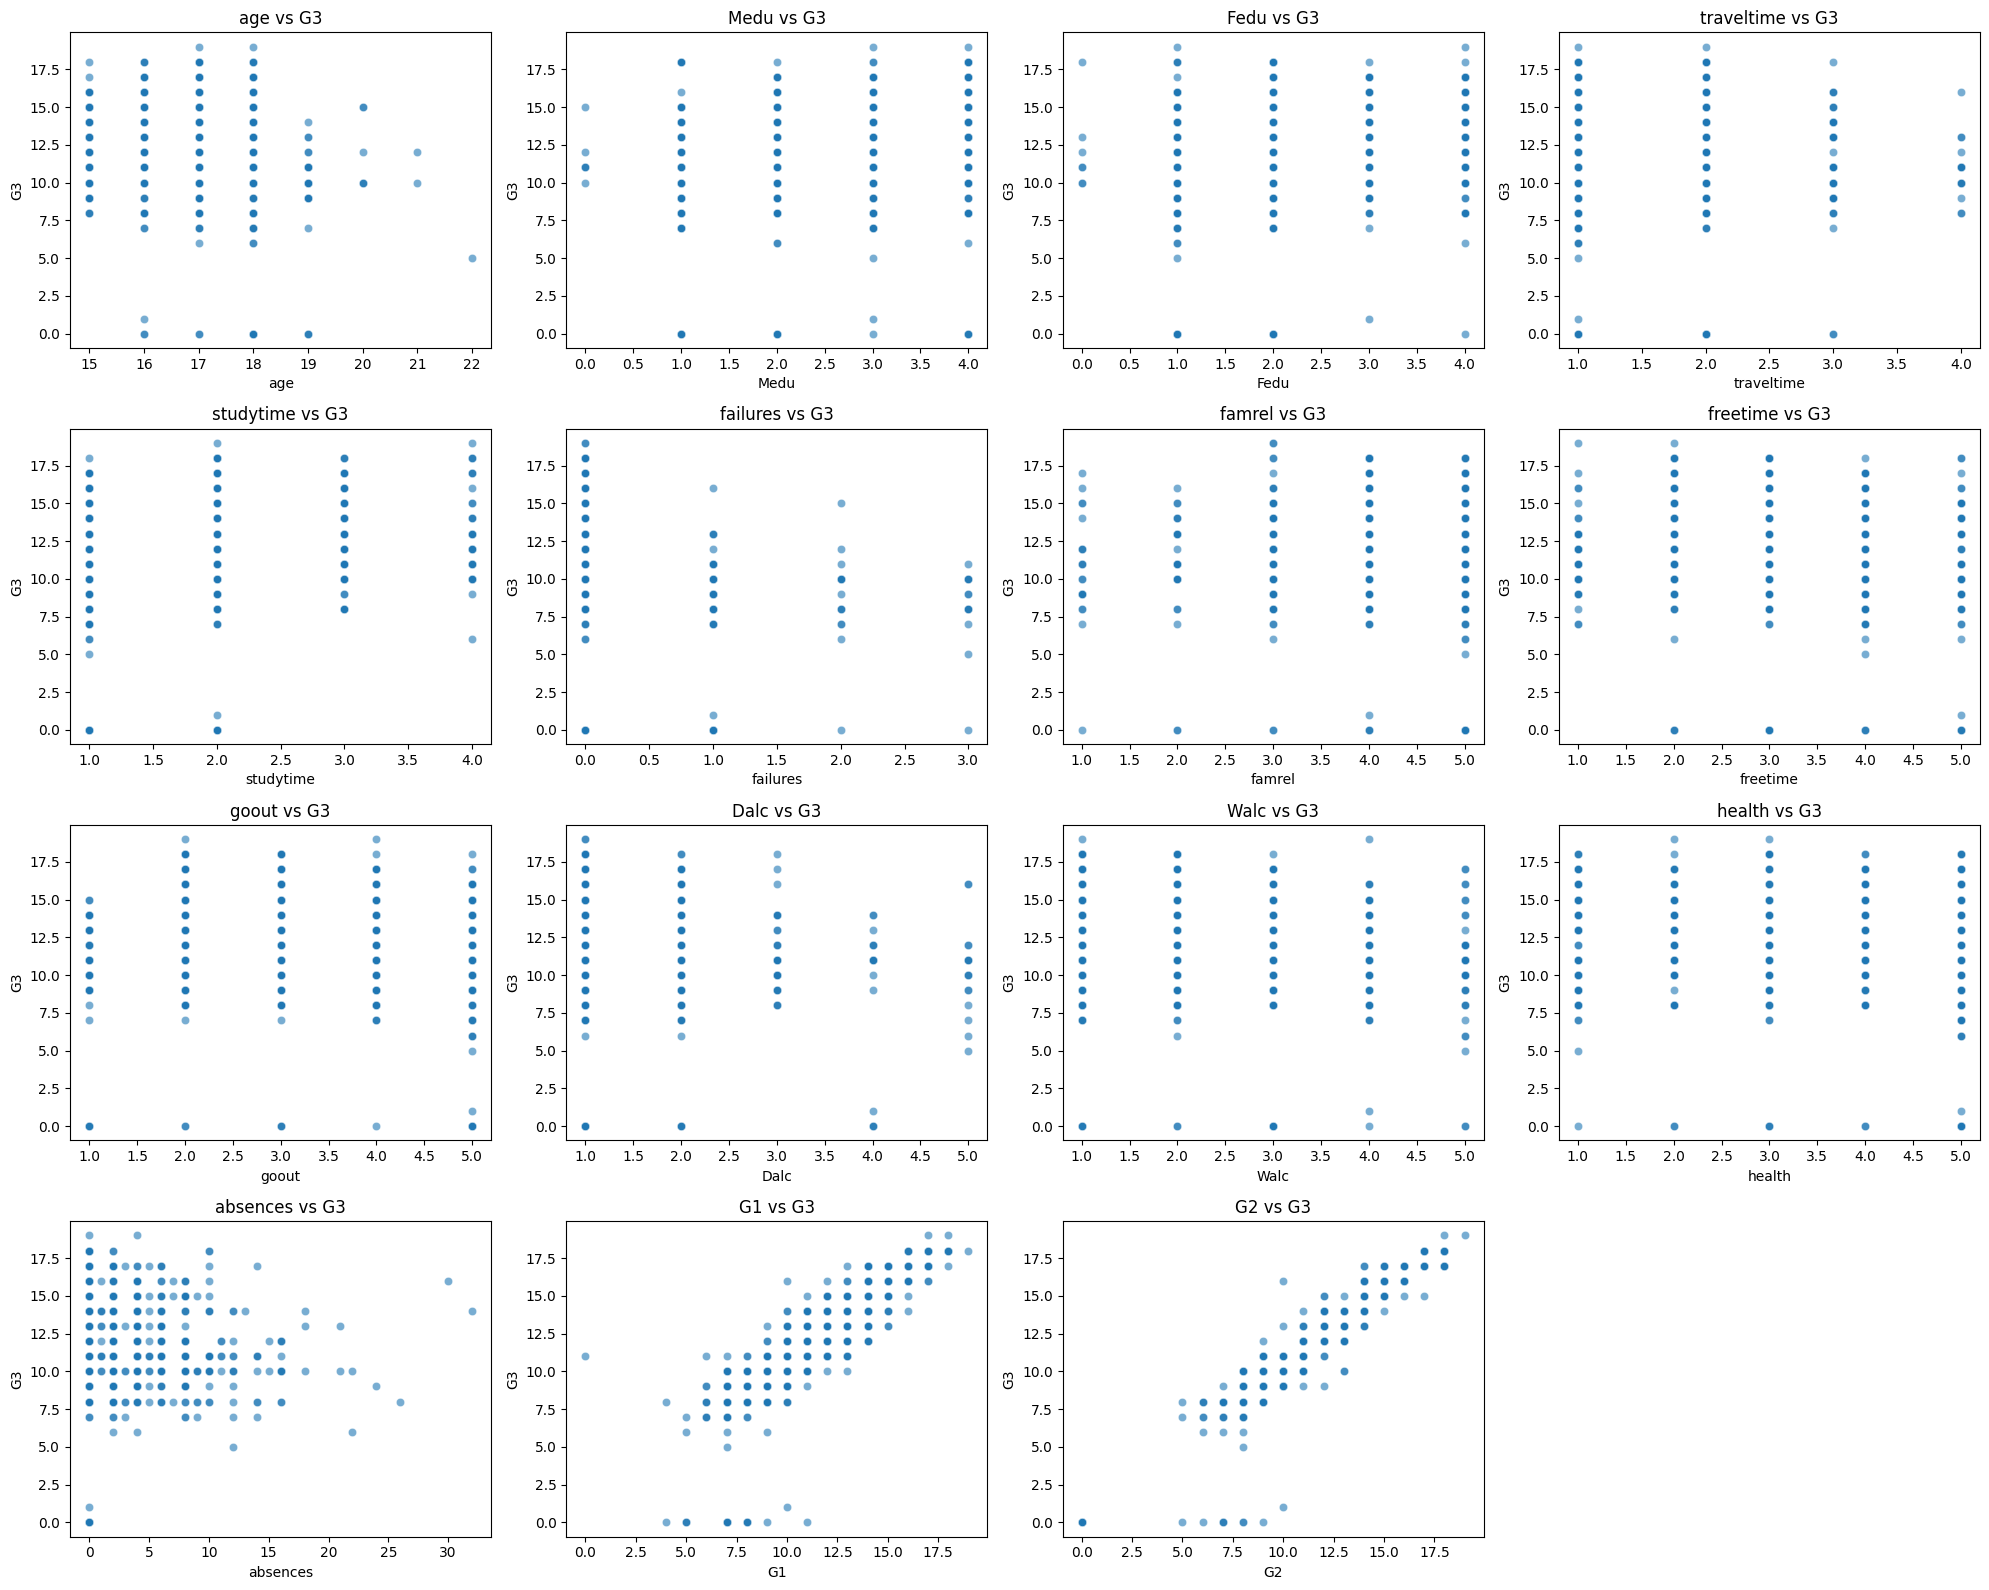

In [ ]:
numerical_cols_for_scatter = df.select_dtypes(include=['int64', 'float64']).columns.drop('G3')

n_cols = 4  # Anda bisa menyesuaikan jumlah kolom di sini
n_rows = math.ceil(len(numerical_cols_for_scatter) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten() # Meratakan array axes agar mudah diiterasi

for i, col in enumerate(numerical_cols_for_scatter):
    if i < len(axes):
        sns.scatterplot(data=df, x=col, y='G3', ax=axes[i], alpha=0.6)
        axes[i].set_title(f'{col} vs G3')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('G3')

# Menghilangkan subplot yang kosong jika ada
for j in range(len(numerical_cols_for_scatter), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

print("ANOVA Test Results for Categorical Variables vs G3:\n")

for col in categorical_cols:
    # Get unique categories for the current column
    categories = df[col].unique()

    # Prepare a list of 'G3' scores for each category
    groups = []
    for category in categories:
        groups.append(df[df[col] == category]['G3'])

    # Perform ANOVA only if there is more than one group and each group has data
    # Also, ensure there's enough variance within groups to perform ANOVA meaningfully
    if len(groups) > 1 and all(len(g) > 1 for g in groups):
        f_statistic, p_value = f_oneway(*groups)
        print(f"Variable: {col}")
        print(f"  F-statistic: {f_statistic:.3f}")
        print(f"  P-value: {p_value:.3f}")
        if p_value < 0.05:
            print("  -> Significant (p < 0.05): There is a statistically significant difference in G3 means across categories.")
        else:
            print("  -> Not Significant (p >= 0.05): No statistically significant difference in G3 means across categories.")
        print("-" * 50)
    else:
        print(f"Variable: {col} - Not enough groups or data points to perform ANOVA.\n")


ANOVA Test Results for Categorical Variables vs G3:

Variable: school
  F-statistic: 56.891
  P-value: 0.000
  -> Significant (p < 0.05): There is a statistically significant difference in G3 means across categories.
--------------------------------------------------
Variable: sex
  F-statistic: 10.962
  P-value: 0.001
  -> Significant (p < 0.05): There is a statistically significant difference in G3 means across categories.
--------------------------------------------------
Variable: address
  F-statistic: 18.708
  P-value: 0.000
  -> Significant (p < 0.05): There is a statistically significant difference in G3 means across categories.
--------------------------------------------------
Variable: famsize
  F-statistic: 1.314
  P-value: 0.252
  -> Not Significant (p >= 0.05): No statistically significant difference in G3 means across categories.
--------------------------------------------------
Variable: Pstatus
  F-statistic: 0.000
  P-value: 0.985
  -> Not Significant (p >= 0.05): No

# Data Preprocessing

## Feature Selection

In [ ]:
df = df[['G1', 'G2', 'G3', 'school', 'reason', 'higher', 'internet', 'romantic']]

## Outlier Handling

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("--- Pemeriksaan Outlier Menggunakan Metode IQR untuk Semua Kolom Numerik ---")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_iqr = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    if not outliers_iqr.empty:
        print(f"\nKolom '{col}': {len(outliers_iqr)} outlier ditemukan menggunakan IQR. Contoh outlier:")
        display(outliers_iqr[[col]].head())
    else:
        print(f"\nKolom '{col}': Tidak ditemukan outlier menggunakan metode IQR.")
    print("-" * 70)

--- Pemeriksaan Outlier Menggunakan Metode IQR untuk Semua Kolom Numerik ---

Kolom 'G1': 16 outlier ditemukan menggunakan IQR. Contoh outlier:


,G1
0,0
113,18
332,18
338,18
344,18


----------------------------------------------------------------------

Kolom 'G2': 25 outlier ditemukan menggunakan IQR. Contoh outlier:


,G2
196,18
240,18
332,18
337,18
338,19


----------------------------------------------------------------------

Kolom 'G3': 16 outlier ditemukan menggunakan IQR. Contoh outlier:


,G3
163,0
172,1
440,0
519,0
563,0


----------------------------------------------------------------------


In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("--- Melakukan Capping Outlier Menggunakan Metode IQR ---")

df_capped = df.copy() # Membuat salinan DataFrame untuk menyimpan data yang sudah di-capping

for col in numerical_cols:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Menghitung jumlah outlier sebelum capping
    outliers_before_capping = df_capped[(df_capped[col] < lower_bound) | (df_capped[col] > upper_bound)]

    if not outliers_before_capping.empty:
        # Melakukan capping
        df_capped[col] = np.where(df_capped[col] < lower_bound, lower_bound, df_capped[col])
        df_capped[col] = np.where(df_capped[col] > upper_bound, upper_bound, df_capped[col])
        print(f"Kolom '{col}': {len(outliers_before_capping)} outlier di-capping. Batas bawah: {lower_bound:.2f}, Batas atas: {upper_bound:.2f}")
    else:
        print(f"Kolom '{col}': Tidak ada outlier yang perlu di-capping.")

print("\nCapping outlier selesai. Berikut adalah ringkasan statistik setelah capping untuk beberapa kolom:")
display(df_capped[numerical_cols].describe())

--- Melakukan Capping Outlier Menggunakan Metode IQR ---
Kolom 'G1': 16 outlier di-capping. Batas bawah: 5.50, Batas atas: 17.50
Kolom 'G2': 25 outlier di-capping. Batas bawah: 5.50, Batas atas: 17.50
Kolom 'G3': 16 outlier di-capping. Batas bawah: 4.00, Batas atas: 20.00

Capping outlier selesai. Berikut adalah ringkasan statistik setelah capping untuk beberapa kolom:


,G1,G2,G3
count,649.000000,649.000000,649.000000
mean,11.408320,11.618644,12.003082
std,2.679597,2.691684,2.916533
min,5.500000,5.500000,4.000000
25%,10.000000,10.000000,10.000000
50%,11.000000,11.000000,12.000000
75%,13.000000,13.000000,14.000000
max,17.500000,17.500000,19.000000


## Encoding

In [ ]:
df_encoded = df_capped.copy() # Mulai dari DataFrame yang sudah di-capping

# Identifikasi kolom kategorikal (object type)
categorical_cols = df_encoded.select_dtypes(include='object').columns

# Pisahkan kolom biner dan multi-kategori
binary_cols = []
multi_category_cols = []

for col in categorical_cols:
    if df_encoded[col].nunique() <= 2:
        binary_cols.append(col)
    else:
        multi_category_cols.append(col)

print(f"Kolom Biner: {binary_cols}")
print(f"Kolom Multi-Kategori: {multi_category_cols}\n")

# --- Label Encoding untuk kolom biner ---
for col in binary_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f"'{col}' di-encode menggunakan LabelEncoder.")

# --- One-Hot Encoding untuk kolom multi-kategori ---
if multi_category_cols:
    # Buat ColumnTransformer untuk One-Hot Encoding
    ct = ColumnTransformer(
        transformers=[
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False), multi_category_cols)
        ],
        remainder='passthrough' # Biarkan kolom lain apa adanya
    )

    # Terapkan One-Hot Encoding pada DataFrame
    # ct.fit_transform mengembalikan numpy array, perlu diubah kembali ke DataFrame
    transformed_data = ct.fit_transform(df_encoded)

    # Dapatkan nama kolom baru setelah One-Hot Encoding
    # Ini sedikit tricky karena OneHotEncoder tidak langsung memberikan nama yang mudah
    # Kita bisa membuat nama kolom secara manual atau menggunakan get_feature_names_out
    new_column_names = ct.named_transformers_['encoder'].get_feature_names_out(multi_category_cols)

    # Gabungkan kembali dengan kolom yang tidak di-encode (numerical dan binary yang sudah di-encode)
    # Pastikan urutan kolom sesuai dengan 'remainder'
    other_cols_df = df_encoded.drop(columns=multi_category_cols)
    df_encoded = pd.concat([
        pd.DataFrame(transformed_data[:, :len(new_column_names)], columns=new_column_names),
        other_cols_df
    ], axis=1)

    print(f"\nKolom {multi_category_cols} di-encode menggunakan OneHotEncoder.")

print("\nEncoding selesai. Berikut adalah info DataFrame setelah encoding:")
df_encoded.info()
display(df_encoded.head())

Kolom Biner: ['school', 'higher', 'internet', 'romantic']
Kolom Multi-Kategori: ['reason']

'school' di-encode menggunakan LabelEncoder.
'higher' di-encode menggunakan LabelEncoder.
'internet' di-encode menggunakan LabelEncoder.
'romantic' di-encode menggunakan LabelEncoder.

Kolom ['reason'] di-encode menggunakan OneHotEncoder.

Encoding selesai. Berikut adalah info DataFrame setelah encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   reason_course      649 non-null    float64
 1   reason_home        649 non-null    float64
 2   reason_other       649 non-null    float64
 3   reason_reputation  649 non-null    float64
 4   G1                 649 non-null    float64
 5   G2                 649 non-null    float64
 6   G3                 649 non-null    float64
 7   school             649 non-null    int64  
 8   higher      

,reason_course,reason_home,reason_other,reason_reputation,G1,G2,G3,school,higher,internet,romantic
0,1.0,0.0,0.0,0.0,5.5,11.0,11.0,0,1,0,0
1,1.0,0.0,0.0,0.0,9.0,11.0,11.0,0,1,1,0
2,0.0,0.0,1.0,0.0,12.0,13.0,12.0,0,1,1,0
3,0.0,1.0,0.0,0.0,14.0,14.0,14.0,0,1,1,1
4,0.0,1.0,0.0,0.0,11.0,13.0,13.0,0,1,0,0


In [ ]:
print("--- Mapping Label Encoding untuk Kolom Biner ---")
for col in binary_cols:
    le = LabelEncoder()
    # Fit on the original (uncapped) df, but only on the selected columns for consistency
    le.fit(df_capped[col])
    print(f"Kolom '{col}':")
    for i, category in enumerate(le.classes_):
        print(f"  '{category}' -> {i}")

print("\n--- Mapping One-Hot Encoding untuk Kolom Multi-Kategori ---")
if multi_category_cols:
    # Re-initialize and fit the ColumnTransformer to get access to categories_
    # This is necessary because the original 'ct' was used to transform df_encoded,
    # and we need to fit it again on the relevant columns from df_encoded
    ct_display = ColumnTransformer(
        transformers=[
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False), multi_category_cols)
        ],
        remainder='passthrough' # Biarkan kolom lain apa adanya
    )
    # Fit only on the relevant categorical columns from df_capped to get the categories
    ct_display.fit(df_capped[multi_category_cols])

    onehot_categories = ct_display.named_transformers_['encoder'].categories_

    for i, col_name in enumerate(multi_category_cols):
        print(f"Kolom '{col_name}':")
        for category in onehot_categories[i]:
            print(f"  '{category}' -> akan menjadi kolom: {col_name}_{category} (nilai 0 atau 1)")
else:
    print("Tidak ada kolom multi-kategori yang di-encode.")

--- Mapping Label Encoding untuk Kolom Biner ---
Kolom 'school':
  'GP' -> 0
  'MS' -> 1
Kolom 'higher':
  'no' -> 0
  'yes' -> 1
Kolom 'internet':
  'no' -> 0
  'yes' -> 1
Kolom 'romantic':
  'no' -> 0
  'yes' -> 1

--- Mapping One-Hot Encoding untuk Kolom Multi-Kategori ---
Kolom 'reason':
  'course' -> akan menjadi kolom: reason_course (nilai 0 atau 1)
  'home' -> akan menjadi kolom: reason_home (nilai 0 atau 1)
  'other' -> akan menjadi kolom: reason_other (nilai 0 atau 1)
  'reputation' -> akan menjadi kolom: reason_reputation (nilai 0 atau 1)


## Train Test Split

In [ ]:
# Memisahkan fitur (X) dan target (y)
X = df_encoded.drop('G3', axis=1) # G2, G1, and G3 are related to student grades, hence G2 is used as target variable
y = df_encoded['G3']

# Melakukan train-test split (misalnya, 80% data training, 20% data testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Bentuk X_train: {X_train.shape}")
print(f"Bentuk X_test: {X_test.shape}")
print(f"Bentuk y_train: {y_train.shape}")
print(f"Bentuk y_test: {y_test.shape}")

Bentuk X_train: (519, 10)
Bentuk X_test: (130, 10)
Bentuk y_train: (519,)
Bentuk y_test: (130,)


# Training & Evaluation

## Linear Regression

In [ ]:
# Latih model menggunakan data training
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)

# Lakukan prediksi pada data testing
y_pred = pipeline.predict(X_test)

# Hitung metrik evaluasi
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Hasil Evaluasi Model Linear Regression ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2 Score): {r2:.4f}")

--- Hasil Evaluasi Model Linear Regression ---
Mean Absolute Error (MAE): 0.6859
Mean Squared Error (MSE): 0.8880
Root Mean Squared Error (RMSE): 0.9423
R-squared (R2 Score): 0.8952


# Model Deployment

In [ ]:
joblib.dump(pipeline, "grade_predictor_model.pkl")

['grade_predictor_model.pkl']